In [1]:
# Young strok definition based on https://pubmed.ncbi.nlm.nih.gov/37048683/
YOUNG_AGE_FEMALE = 54
YOUNG_AGE_MALE   = 52

In [2]:
from dask.distributed import Client
client = Client(n_workers=24, threads_per_worker=1, processes=True, memory_limit='64GB')
client

/home/asadr/Downloads/yes/envs/eda/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38407 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:38407/status,
Dashboard: http://127.0.0.1:38407/status,Workers: 24
Total threads: 24,Total memory: 1.40 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42495,Workers: 24
Dashboard: http://127.0.0.1:38407/status,Total threads: 24
Started: Just now,Total memory: 1.40 TiB
Comm: tcp://127.0.0.1:38885,Total threads: 1
Dashboard: http://127.0.0.1:36455/status,Memory: 59.60 GiB
Nanny: tcp://127.0.0.1:38849,


In [3]:
import os
import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sns
import geopandas as gpd
import warnings
from glob import glob
from tqdm import tqdm
from zipfile import ZipFile
from scipy.stats import pearsonr, kurtosis, skew, moment, normaltest, levene, ttest_ind, norm
from scipy.interpolate import interp1d
import statsmodels.formula.api as smf
from shapely.geometry import Polygon
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1 import make_axes_locatable
# import missingno as msno
import dask.dataframe as dd
import dask
# import polars as pl
import matplotlib.gridspec as gridspec

import docx
import scipy.stats as stats
# Plotting settings
import scienceplots
import matplotlib
STYLE = ['science', 'nature']
# STYLE = 'ggplot'

# Suppress warnings
pd.options.mode.chained_assignment = None  # Suppress chained assignment warning
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Set environment variable for Bokeh logging
os.environ['BOKEH_LOG_LEVEL'] = 'fatal'
%matplotlib inline

In [4]:
def compare_columns_by_pval(df,col):
    # Get the unique values of sex
    sexes = df[col].unique()
    
    # Initialize a dictionary to store p-values
    p_values = {}
    
    # Iterate over each column except 'sex'
    for column in df.columns:
        if column != col:
            # Split the column based on sex
            group1 = df[df[col] == sexes[0]][column]
            group2 = df[df[col] == sexes[1]][column]
            
            # Perform t-test and store the p-value
            # t_stat, p_val = ttest_ind(group1, group2, nan_policy='omit')

            _,p1 = levene(group1, group2)
            _,p_val = ttest_ind(group1, group2, equal_var=p1>0.05, nan_policy='omit')
            p_values[column] = p_val
    
    # Convert the dictionary to a DataFrame
    p_values_df = pd.DataFrame(list(p_values.items()), columns=['Column', 'P-Value'])
    
    return p_values_df

def give_star(pv):
    """Convert p-value to stars"""
    if pv > 0.05:
        return '*'
    elif pv <= 0.05 and pv > 0.01:
        return '**'
    elif pv <= 0.01 and pv > 0.001:
        return '***'
    elif pv <= 0.001:
        return '****'


def to_docx(df_,fname):
    doc = docx.Document()

    # add a table to the end and create a reference variable
    # extra row is so we can add the header row
    t = doc.add_table(df_.shape[0]+1, df_.shape[1])
    # set table style to Table Grid
    t.style = 'Table Grid'

    # add the header rows.
    for j in range(df_.shape[-1]):
        t.cell(0,j).text = df_.columns[j]

    # add the rest of the data frame
    for i in range(df_.shape[0]):
        for j in range(df_.shape[-1]):
            t.cell(i+1,j).text = str(df_.values[i,j])

    # save the doc
    doc.save(fname)
    
clrs = ['r','b','g','y','plum','sienna','darkolivegreen',
'orange','cyan','violet','lime','darkblue','maroon','greenyellow','lightpink','thistle']

palette = sns.set_palette( [(1, 0, 0, 0.5), (0, 0, 1, 0.5), (0, 1, 0, 0.5)] )

# clrs_with_alpha = [(color, 0.7) for color in clrs]
# # Create a custom color palette
# custom_palette = sns.color_palette(clrs_with_alpha)
# palette = sns.set_palette( clrs )


def get_pvalue(g1, g2):
    # Check normality using Kolmogorov-Smirnov test
    if len(g1)*len(g2)==0: return np.nan
    stat_g1, p_g1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
    stat_g2, p_g2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))
    
    # Check equal variances
    stat, p = stats.levene(g1, g2)
    
    if p_g1 > 0.05 and p_g2 > 0.05:
        if p > 0.05:  # Both normally distributed and equal variances
            t_statistic, p_value = stats.ttest_ind(g1, g2, equal_var=True)
        else:
            t_statistic, p_value = stats.ttest_ind(g1, g2, equal_var=False)
    else:
        # Use Mann-Whitney U test if not normally distributed or variances are not equal
        u_statistic, p_value = stats.mannwhitneyu(g1, g2)
    
    return p_value

# Function to calculate 68% confidence interval
# CI = 0.68
# CI = 0.95
CI = 0.997
def lower_ci(series):
    mean = series.mean()
    std = series.std()
    ci = norm.interval(CI, loc=mean, scale=std / np.sqrt(len(series)))
    return ci[0]

def upper_ci(series):
    mean = series.mean()
    std = series.std()
    ci = norm.interval(CI, loc=mean, scale=std / np.sqrt(len(series)))
    return ci[1]

In [5]:
# ICD codes containing ICD9 and ICD10 to recognize stroke patients

icd9s_IS = ['433.01', '433.11', '433.21', '433.31', '433.81', '433.91', '434.01', '434.11', '434.91']

icd10s_IS = [
    'H34.1', 'I63', 'I63.0', 'I63.00', 'I63.01', 'I63.011', 'I63.012', 'I63.013', 'I63.019', 'I63.02', 'I63.03', 'I63.031', 'I63.032', 'I63.033', 'I63.039', 
    'I63.09', 'I63.1', 'I63.10', 'I63.11', 'I63.111', 'I63.112', 'I63.113', 'I63.119', 'I63.12', 'I63.13', 'I63.131', 'I63.132', 'I63.133', 'I63.139', 
    'I63.19', 'I63.2', 'I63.20', 'I63.21', 'I63.211', 'I63.212', 'I63.213', 'I63.219', 'I63.22', 'I63.23', 'I63.231', 'I63.232', 'I63.233', 'I63.239', 
    'I63.29', 'I63.3', 'I63.30', 'I63.31', 'I63.311', 'I63.312', 'I63.313', 'I63.319', 'I63.32', 'I63.321', 'I63.322', 'I63.323', 'I63.329', 'I63.33', 
    'I63.331', 'I63.332', 'I63.333', 'I63.339', 'I63.34', 'I63.341', 'I63.342', 'I63.343', 'I63.349', 'I63.39', 'I63.4', 'I63.40', 'I63.41', 'I63.411', 
    'I63.412', 'I63.413', 'I63.419', 'I63.42', 'I63.421', 'I63.422', 'I63.423', 'I63.429', 'I63.43', 'I63.431', 'I63.432', 'I63.433', 'I63.439', 'I63.44', 
    'I63.441', 'I63.442', 'I63.443', 'I63.449', 'I63.49', 'I63.5', 'I63.50', 'I63.51', 'I63.511', 'I63.512', 'I63.513', 'I63.519', 'I63.52', 'I63.521', 
    'I63.522', 'I63.523', 'I63.529', 'I63.53', 'I63.531', 'I63.532', 'I63.533', 'I63.539', 'I63.54', 'I63.541', 'I63.542', 'I63.543', 'I63.549', 'I63.59', 
    'I63.6', 'I63.8', 'I63.81', 'I63.89', 'I63.9'
]

icds = icd9s_IS+icd10s_IS

# icd9s = icd9s_IS+icd10s_IS
# icd10s = 

base_dir = '/home/asadr/datasets/'
tabs = sorted(glob(f'{base_dir}TriNetX/dataset_64b01b62c6dca15375ae9828_stroke/*.csv'))
# tabs

## Table 1 to show the CPT codes used to extract imaging modalities

In [6]:
# Extracting all replated imaging procedures 

df_cpts = pd.read_csv('../radio/2024_DHS_Code_List_Addendum_11_29_2023.csv').loc[:1241,['CPTcode','description']].dropna()

df_tot = pd.DataFrame(columns=['category','CPTcode','description'])

df_ = df_cpts[df_cpts['description'].str.startswith('Mr angiography head')]#['CPTcode'].values
df_ = df_.assign(category='MRA')
df_tot = pd.concat([df_tot,df_])
df_tot

filt1 = df_cpts['description'].str.startswith('Mri head')
filt2 = df_cpts['description'].str.startswith('Mri brain')

df_ = df_cpts[(filt1) | (filt2)]#['CPTcode'].values

df_ = df_.assign(category='MRI')
df_tot = pd.concat([df_tot,df_])

df_ = df_cpts[df_cpts['description'].str.startswith('Ct angiography head')]#['CPTcode'].values
df_ = df_.assign(category='CTA')
df_tot = pd.concat([df_tot,df_])
df_tot


filt1 = df_cpts['description'].str.startswith('Ct head/brain')
filt2 = df_cpts['description'].str.startswith('CT brain')

df_ = df_cpts[(filt1) | (filt2)]#['CPTcode'].values

df_ = df_.assign(category='CT')
df_tot = pd.concat([df_tot,df_])

cpt_codes = df_tot['CPTcode'].values

name = 'CPTcodes'
to_docx(df_tot,f'results/tables_age/disparity_age-{name}.docx')
df_tot

,category,CPTcode,description
459,MRA,70544,Mr angiography head w/o dye
460,MRA,70545,Mr angiography head w/dye
465,MRI,70551,Mri brain w/o dye
466,MRI,70552,Mri brain w/dye
467,MRI,70553,Mri brain w/o & w/dye
454,CTA,70496,Ct angiography head
442,CT,70450,Ct head/brain w/o dye
443,CT,70460,Ct head/brain w/dye
444,CT,70470,Ct head/brain w/o & w/dye


In [7]:
df_tot.to_csv('df_tot_CPT_codes.csv',index=0)

# TriNetX data preparation

In [8]:
ii = 14
df_px = dd.read_parquet(tabs[ii].replace('.csv',''))[['patient_id','code','date']].rename(columns={'code':'code_px','date':'date_px'})
cols = list(df_px.columns)
print(df_px.columns)

filt_cpt = df_px['code_px'].isin(cpt_codes)
df_px = df_px[filt_cpt]
filt = df_px['date_px'].str.startswith(('2018','2019'))
df_px = df_px[filt]
df_px = df_px.compute()

ii = 5
df_dx = dd.read_parquet(tabs[ii].replace('.csv',''))[[
    'patient_id','code','date','principal_diagnosis_indicator'
]].rename(columns={'code':'code_dx','date':'date_dx'})
print(tabs[ii])
cols = list(df_dx.columns)
df_dx = df_dx[df_dx['principal_diagnosis_indicator']=='P']
print(df_dx.columns)

filt_icd = df_dx['code_dx'].isin(icds)
df_dx = df_dx[filt_icd]
filt = df_dx['date_dx'].str.startswith(('2018','2019'))
df_dx = df_dx[filt].compute()

df_px['datetime_px'] = pd.to_datetime(df_px['date_px'],format='%Y%m%d',errors='coerce')
df_dx['datetime_dx'] = pd.to_datetime(df_dx['date_dx'],format='%Y%m%d',errors='coerce')

# We assume one person can get one imaging of each modality in a day
df_px_ = df_px.drop_duplicates()
df_dx_ = df_dx.drop_duplicates()

df_merged = df_px_.merge(df_dx_,on='patient_id',how='left').dropna()

df_merged['d2ptime'] = df_merged['datetime_px']-df_merged['datetime_dx']
df_merged['ispOK'] = (df_merged['d2ptime']>=pd.Timedelta('-7 days')) & (df_merged['d2ptime']<=pd.Timedelta('7 days'))
df_merged = df_merged[df_merged['ispOK']]

df_merged = df_merged.drop_duplicates(subset=['patient_id','code_px','date_px'])

df_merged.loc[df_merged['code_dx'].isin(icd9s_IS+icd10s_IS),'Stroke'] = 'Ischemic'

df_merged = df_merged.merge(df_tot[['category','CPTcode']],left_on='code_px', right_on='CPTcode',how='left').drop(columns=['code_px'])

df_merged['year_dx'] = df_merged['datetime_dx'].apply(lambda x:int(str(x)[:4]))

df_merged.to_parquet('df_merged_age.parquet')

# load merged data

In [8]:
df_merged = pd.read_parquet('df_merged_age.parquet')
prefix_fig = 'overall'
print(df_merged.shape,df_merged['patient_id'].nunique())

patid_wct = df_merged[df_merged['category']=='CT']['patient_id'].unique()
df_merged = df_merged[df_merged['patient_id'].isin(patid_wct)]
df_merged = df_merged[df_merged['category']!='CT']
print(df_merged.shape,df_merged['patient_id'].nunique())

(1025641, 13) 413361
(408614, 13) 225084


In [9]:
df_merged.head(3)

,patient_id,date_px,datetime_px,code_dx,date_dx,principal_diagnosis_indicator,datetime_dx,d2ptime,ispOK,Stroke,category,CPTcode,year_dx
6,VwBJ,20191119,2019-11-19,I63.232,20191119,P,2019-11-19,0 days,True,Ischemic,CTA,70496,2019
7,VwBJ,20190712,2019-07-12,I63.9,20190712,P,2019-07-12,0 days,True,Ischemic,MRI,70553,2019
8,VwBJ,20191119,2019-11-19,I63.232,20191119,P,2019-11-19,0 days,True,Ischemic,MRI,70553,2019


In [10]:
# df_merged = df_merged.sort_values('datetime_dx').groupby(['Stroke','patient_id'], as_index=False).first()
# prefix_fig = 'p_1st_procedure'
# df_merged.shape,df_merged['patient_id'].nunique()

In [11]:
# Convert datetime_dx to datetime
df_merged['datetime_dx'] = pd.to_datetime(df_merged['datetime_dx'])

# Create a mask for the earliest diagnosis date for each patient
earliest_dx_mask = df_merged.groupby(['Stroke', 'patient_id'])['datetime_dx'].transform('min') == df_merged['datetime_dx']

# Filter the dataframe based on the mask
df_merged = df_merged[earliest_dx_mask]

prefix_fig = 'p_1st_visit'
df_merged.shape,df_merged['patient_id'].nunique()

((369768, 13), 225084)

In [12]:
df_merged.head(3)

,patient_id,date_px,datetime_px,code_dx,date_dx,principal_diagnosis_indicator,datetime_dx,d2ptime,ispOK,Stroke,category,CPTcode,year_dx
7,VwBJ,20190712,2019-07-12,I63.9,20190712,P,2019-07-12,0 days,True,Ischemic,MRI,70553,2019
10,VwCJ,20190924,2019-09-24,I63.9,20190923,P,2019-09-23,1 days,True,Ischemic,CTA,70496,2019
11,VwCJ,20190923,2019-09-23,I63.9,20190923,P,2019-09-23,0 days,True,Ischemic,MRI,70551,2019


In [13]:
df_2018_isc = df_merged.set_index(['year_dx','Stroke']).loc[(2018,'Ischemic')][['patient_id', 'category']].groupby(['patient_id', 'category']).size().unstack(fill_value=0).reset_index()
df_2019_isc = df_merged.set_index(['year_dx','Stroke']).loc[(2019,'Ischemic')][['patient_id', 'category']].groupby(['patient_id', 'category']).size().unstack(fill_value=0).reset_index()

/tmp/ipykernel_935986/1598495384.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_2018_isc = df_merged.set_index(['year_dx','Stroke']).loc[(2018,'Ischemic')][['patient_id', 'category']].groupby(['patient_id', 'category']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_935986/1598495384.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_2019_isc = df_merged.set_index(['year_dx','Stroke']).loc[(2019,'Ischemic')][['patient_id', 'category']].groupby(['patient_id', 'category']).size().unstack(fill_value=0).reset_index()


In [14]:
ii = 12
print(tabs[ii])
df_dem = dd.read_parquet(tabs[ii].replace('.csv',''))[['patient_id','sex','race','ethnicity','year_of_birth','postal_code']]
cols_dem = list(df_dem.columns)
df_dem.columns

/home/asadr/datasets/TriNetX/dataset_64b01b62c6dca15375ae9828_stroke/patient.csv


Index(['patient_id', 'sex', 'race', 'ethnicity', 'year_of_birth',
       'postal_code'],
      dtype='object')

In [15]:
df_dem = df_dem[df_dem['patient_id'].isin(df_merged['patient_id'])].compute()

In [16]:
df_dem = df_dem.replace('XXX', np.nan)
df_dem['postal_code'] = pd.to_numeric(df_dem['postal_code'],errors='coerce')
df_dem = df_dem.dropna(subset=['postal_code','year_of_birth'])
df_dem['ethnicity'] = df_dem['ethnicity'].replace({'Not Hispanic or Latino':'Non-Hispanic','Hispanic or Latino':'Hispanic'})
df_dem['race'] = df_dem['race'].replace({'Black or African American':'Black'})
df_dem['year_of_birth'] = df_dem['year_of_birth'].astype(int)

In [17]:
df_2018_isc = df_2018_isc.merge(df_dem,on='patient_id',how='left')
df_2019_isc = df_2019_isc.merge(df_dem,on='patient_id',how='left')

df_2018_isc['age@stroke'] = 2018-df_2018_isc['year_of_birth']
df_2019_isc['age@stroke'] = 2019-df_2019_isc['year_of_birth']

In [18]:
df_2018_isc[
    ((df_2018_isc["sex"].str.upper().isin(["F","FEMALE"])) &
     (df_2018_isc["age@stroke"] <= YOUNG_AGE_FEMALE))
    |
    ((df_2018_isc["sex"].str.upper().isin(["M","MALE"])) &
     (df_2018_isc["age@stroke"] <= YOUNG_AGE_MALE))
]['patient_id'].nunique()+df_2019_isc[
    ((df_2019_isc["sex"].str.upper().isin(["F","FEMALE"])) &
     (df_2019_isc["age@stroke"] <= YOUNG_AGE_FEMALE))
    |
    ((df_2019_isc["sex"].str.upper().isin(["M","MALE"])) &
     (df_2019_isc["age@stroke"] <= YOUNG_AGE_MALE))
]['patient_id'].nunique()

31040

In [19]:
df_2018_isc = df_2018_isc[
    ((df_2018_isc["sex"].str.upper().isin(["F","FEMALE"])) &
     (df_2018_isc["age@stroke"] <= YOUNG_AGE_FEMALE) &
     (df_2018_isc["age@stroke"] > 18))
    |
    ((df_2018_isc["sex"].str.upper().isin(["M","MALE"])) &
     (df_2018_isc["age@stroke"] <= YOUNG_AGE_MALE) &
     (df_2018_isc["age@stroke"] > 18))
].copy()

df_2019_isc = df_2019_isc[
    ((df_2019_isc["sex"].str.upper().isin(["F","FEMALE"])) &
     (df_2019_isc["age@stroke"] <= YOUNG_AGE_FEMALE) &
     (df_2019_isc["age@stroke"] > 18))
    |
    ((df_2019_isc["sex"].str.upper().isin(["M","MALE"])) &
     (df_2019_isc["age@stroke"] <= YOUNG_AGE_MALE) &
     (df_2019_isc["age@stroke"] > 18))
].copy()

In [20]:
df_2018_isc['patient_id'].nunique()

15989

In [21]:
df_2018_isc['dx_year'] = 2018
df_2019_isc['dx_year'] = 2019

df_2018_isc['stroke'] = 'Ischemic'
df_2019_isc['stroke'] = 'Ischemic'

In [22]:
df_dem.head(2)

,patient_id,sex,race,ethnicity,year_of_birth,postal_code
9863,CAFx,M,Unknown,Unknown,1951,245
9901,CgOx,M,Unknown,Unknown,1975,981


In [23]:
pat_ids_ = df_dem.dropna(subset=['sex','year_of_birth'])['patient_id']

In [24]:
ii = 5
df_dx = dd.read_parquet(tabs[ii].replace('.csv',''))[[
    'patient_id','code','date','principal_diagnosis_indicator'
]].rename(columns={'code':'code_dx','date':'date_dx'})
df_dx = df_dx[ df_dx.patient_id.isin(pat_ids_) ]
df_dx['date_dx'] = dd.to_datetime(
    df_dx['date_dx'], format='%Y%m%d', errors='coerce'
)
df_dx = df_dx.compute()

In [26]:
# pd.concat([df_2018_isc,df_2019_isc]) , pd.concat([df_2018_hmc,df_2019_hmc])

# Read diagnosis data in parallel
# diagnosis_ddf = dd.read_csv('diagnosis.csv', parse_dates=['date_dx'])
cols = list(df_dx.columns)
stroke_codes = set(icd9s_IS + icd10s_IS)
# Filter diagnoses to only stroke-related entries
stroke_diag = df_dx[ df_dx.code_dx.isin(stroke_codes) ]
stroke_diag = stroke_diag[stroke_diag['principal_diagnosis_indicator']=='P']
year_dx = stroke_diag.date_dx.dt.year
filt = (year_dx > 2017) & (year_dx < 2020)
stroke_diag = stroke_diag[filt]

# Compute first stroke date per patient
first_stroke = stroke_diag.groupby('patient_id').date_dx.min().reset_index()
first_stroke = first_stroke.rename(columns={'date_dx': 'first_stroke_date'})

# Merge stroke patient info with patient demographics
stroke_patients = first_stroke.merge(df_dem, on='patient_id', how='left')
stroke_patients = stroke_patients.dropna(subset=['sex','year_of_birth'])
stroke_patients['age_at_stroke'] = stroke_patients.first_stroke_date.dt.year - stroke_patients.year_of_birth

In [27]:
first_stroke.head(2)

,patient_id,first_stroke_date
0,#A#8,2019-03-08
1,#A#9B,2019-06-22


In [28]:
df_dx.head(2)

,patient_id,code_dx,date_dx,principal_diagnosis_indicator
11262,JRu2B,B95.5,2016-11-17,Unknown
11263,JRu2B,D17.71,2016-11-27,P


In [29]:
# Merge to get stroke date on each diagnosis record, then filter pre-stroke records
diagnosis_with_stroke = df_dx.merge(first_stroke, on='patient_id', how='inner')
pre_stroke_df = diagnosis_with_stroke[ diagnosis_with_stroke.date_dx < diagnosis_with_stroke.first_stroke_date ]

In [30]:
# Define code sets for risk-factor conditions (example codes, not exhaustive)
CHF_codes = ['428', '428.0', '428.1', '428.2', 'I50', 'I50.1']       # CHF (ICD-9 428.* or ICD-10 I50.*)
HTN_codes = ['401', '401.0', '401.1', 'I10', 'I11']                 # Hypertension
DM_codes  = ['250', '250.0', 'E10', 'E11']                         # Diabetes mellitus
Vasc_codes = ['410', '412', '414', '443', '444', 'I25', 'I70', 'I73']  # Vascular disease (MI, PAD, etc.)

# Add flag columns for each condition
pre_stroke_df = pre_stroke_df.assign(
    CHF_flag = pre_stroke_df.code_dx.isin(CHF_codes),
    HTN_flag = pre_stroke_df.code_dx.isin(HTN_codes),
    DM_flag  = pre_stroke_df.code_dx.isin(DM_codes),
    VAS_flag = pre_stroke_df.code_dx.isin(Vasc_codes)
)

# Aggregate flags by patient (any True -> condition present)
risk_flags = pre_stroke_df.groupby('patient_id').agg({
    'CHF_flag': 'max',
    'HTN_flag': 'max',
    'DM_flag': 'max',
    'VAS_flag': 'max'
}).reset_index()



- Congestive heart failure: 1 point
- Hypertension: 1 point
- Age 65–74 years: 1 point
- Age ≥ 75 years: 2 points
- Diabetes mellitus: 1 point
- Vascular disease: 1 point (e.g., prior MI or PAD)
- Sex category (female): 1 point

In [31]:
# Assign age points
# Assign age points
stroke_patients['age_points'] = np.where(stroke_patients['age_at_stroke'] >= 75, 2, 
                                         np.where(stroke_patients['age_at_stroke'] >= 65, 1, 0))

# Assign sex points (female = 1, male = 0)
stroke_patients['sex_points'] = np.where(stroke_patients['sex'].str.lower().isin(['female', 'f']), 1, 0)

# Merge in the risk flags
score_df = stroke_patients.merge(risk_flags, on='patient_id', how='left')

In [32]:
# Merge in the risk flags
score_df = score_df.fillna(0)

# Calculate total CHA2DS2-VASc score
score_df['CHA2DS2_VASc_score'] = (score_df.age_points.astype(int) + score_df.sex_points.astype(int) +
                                  score_df.CHF_flag.astype(int) + score_df.HTN_flag.astype(int) +
                                  score_df.DM_flag.astype(int) + score_df.VAS_flag.astype(int))
# Drop patients with missing age or sex (if any)
score_df = score_df.dropna(subset=['year_of_birth', 'sex', 'CHA2DS2_VASc_score'])

# Select only patient_id and score for output
score_df = score_df[['patient_id', 'CHA2DS2_VASc_score']]
score_df.head(2)

,patient_id,CHA2DS2_VASc_score
0,#A#8,1
1,#A#9B,1


In [33]:
# 311029 if all ages were in
len(pat_ids_)

173490

In [34]:
df_2018_isc = df_2018_isc.merge(score_df,on='patient_id',how='left')
df_2019_isc = df_2019_isc.merge(score_df,on='patient_id',how='left')

In [35]:
df_2018_isc.shape,df_2019_isc.shape
# if all were in all: ((202812, 14), (183011, 14)

((15989, 13), (14630, 13))

In [36]:
df_total = pd.concat([df_2018_isc, df_2019_isc])

In [40]:
df_total.to_parquet('df_trinetx_total_young.parquet',index=0)

# Begin from here

In [37]:
df_total = pd.read_parquet('df_trinetx_total_young.parquet')
df_total = df_total.replace('Unknown', np.nan)
df_total.isna().mean()

patient_id            0.000000
CTA                   0.000000
MRA                   0.000000
MRI                   0.000000
sex                   0.000000
race                  0.764395
ethnicity             0.738953
year_of_birth         0.000000
postal_code           0.000000
age@stroke            0.000000
dx_year               0.000000
stroke                0.000000
CHA2DS2_VASc_score    0.000000
dtype: float64

In [38]:
df_total = pd.read_parquet('df_trinetx_total_young.parquet')

# bins = list( df_total[df_total['stroke']=='Ischemic']['age@stroke'].quantile(np.arange(0,1,0.1)).astype(int).values )
bins = list( df_total['age@stroke'].quantile(np.arange(0,1,1)).astype(int).values )
bins = bins+[150]
labels = [f'{bins[0]}-{bins[1]}']+[f'{bins[i_]+1}-{bins[i_+1]}' for i_ in range(1,len(bins)-1)]
labels[0] = f'<{bins[1]+1}'
labels[-1] = f'{bins[-2]}<'
bins,labels
# Create a new column 'age_group' with the age classes
df_total['age_group'] = pd.cut(df_total['age@stroke'], bins=bins, labels=labels, right=False)

label_conv_dic = {j:i for i,j in enumerate(labels)}
df_total['sex'] = df_total['sex'].replace({'M':'Men','F':'Women'})
df_total.head(2)

,patient_id,CTA,MRA,MRI,sex,race,ethnicity,year_of_birth,postal_code,age@stroke,dx_year,stroke,CHA2DS2_VASc_score,age_group
0,#A#YD,1,0,1,Women,Unknown,Unknown,1969.0,347,49.0,2018,Ischemic,2,19<
1,#A14C,0,0,1,Women,Unknown,Unknown,1975.0,776,43.0,2018,Ischemic,2,19<


In [39]:
df_total[df_total['stroke']=='Ischemic'].groupby('age_group')['patient_id'].size()

/tmp/ipykernel_935986/2646247526.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total[df_total['stroke']=='Ischemic'].groupby('age_group')['patient_id'].size()


age_group
19<    30619
Name: patient_id, dtype: int64

In [40]:
df_total.groupby('sex')['age@stroke'].mean()

sex
Men      44.103001
Women    44.136148
Name: age@stroke, dtype: float64

In [41]:
# Define the colors
clrs = ['r','b','g','y','plum','sienna','darkolivegreen',
        'orange','cyan','violet','lime','darkblue','maroon',
        'greenyellow','lightpink','thistle']

# Create a color palette with alpha 0.7
palette = sns.color_palette(clrs, desat=0.7)

# Figure 1

/tmp/ipykernel_935986/1099884390.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_, x=x, y=y, ax=ax, palette=colors, inner='quartile', order=order)
/tmp/ipykernel_935986/1099884390.py:14: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.violinplot(data=data_, x=x, y=y, ax=ax, palette=colors, inner='quartile', order=order)
/tmp/ipykernel_935986/1099884390.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_, x=x, y=y, ax=ax, palette=colors, inner='quartile', order=order)
/tmp/ipykernel_935986/1099884390.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.v

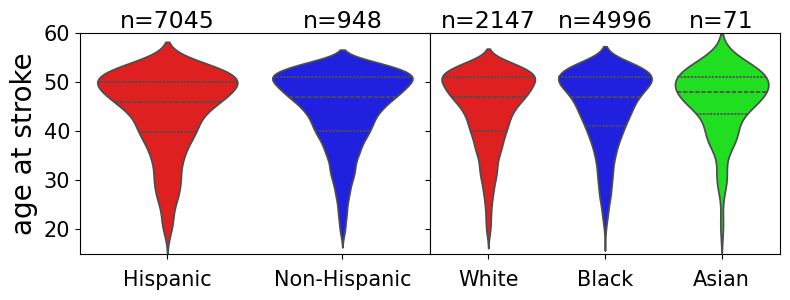

In [42]:
# Create figure with three subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# fig.suptitle('Age at Stroke Distribution by Demographics', fontsize=16, y=1.05)

# Custom color palette suitable for Nature publication
colors = [(1, 0, 0, 0.5), (0, 0, 1, 0.5), (0, 1, 0, 0.5), (0, 1, 0, 0.5)]

# Function to create violin plot with statistical annotations
def create_violin_plot(ax, data, x, y, title, order=None):
    # Create violin plot
    data_ = data[[x,y]].replace('Unknown', np.nan).dropna(subset=[x,y])
    # if x=='sex':
    #     data_ = data_.replace({'M':'Men','F':'Women'})
    sns.violinplot(data=data_, x=x, y=y, ax=ax, palette=colors, inner='quartile', order=order)
    ax.set_ylim(15,60)
    # Customize the plot
    # ax.set_title(title, pad=20)
    ax.set_xlabel('')
    if x=='ethnicity':
        pass
        ax.set_ylabel('age at stroke',fontsize=20)
    else:
        ax.set_ylabel('')
    # ax.set_ylabel('Age at Stroke' if ax == axes[0] else '', fontsize=20)
    # ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(),rotation=0,ha='center',
                       rotation_mode='anchor',fontsize=15)
    ax.tick_params(axis='x', pad=8)

    yticks = list(range(20, 61, 10))
    if x == 'ethnicity':
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontsize=15)
    else:
        ax.set_yticks(yticks)
        ax.set_yticklabels([], fontsize=0)

    
    # Add statistical annotations
    for i, category in enumerate(data_[x].unique()):
        subset = data_[data_[x] == category]
        mean_age = subset[y].mean()
        std_age = subset[y].std()
        ax.text(i, ax.get_ylim()[1], f'n={len(subset)}', 
                ha='center', va='bottom', fontsize=17)


# Create the three violin plots
# create_violin_plot(axes[0], df_total, 'sex', 'age@stroke', 'Age at Stroke by Sex', order=['Men','Women'])
create_violin_plot(axes[0], df_total, 'ethnicity', 'age@stroke', 'Age at Stroke by Ethnicity', order=['Hispanic','Non-Hispanic'])
create_violin_plot(axes[1], df_total, 'race', 'age@stroke', 'Age at Stroke by Race', order=['White','Black','Asian'])

# Adjust layout
plt.tight_layout()

plt.subplots_adjust(wspace=0, top=0.68)

name = 'fig1'
fig.savefig(f'results/figs_young/{name}.pdf')
fig.savefig(f'results/figs_young/{name}.svg')
fig.savefig(f'results/figs_young/{name}.jpg', dpi=300, bbox_inches='tight')

In [43]:
df_total.columns

Index(['patient_id', 'CTA', 'MRA', 'MRI', 'sex', 'race', 'ethnicity',
       'year_of_birth', 'postal_code', 'age@stroke', 'dx_year', 'stroke',
       'CHA2DS2_VASc_score', 'age_group'],
      dtype='object')

In [44]:
df_total['patient_id'].nunique()

30619

## Table 2 to show the demographic of the data in different age groups

In [45]:
for col_ in ['sex','ethnicity','race']:
    # Selecting relevant columns
    df_var = df_total[['dx_year', col_,'age@stroke']].replace({'Unknown':np.nan}).dropna()
        
    # Aggregating mean and 68% CI
    agg_df = df_var.groupby(['dx_year', col_]).agg(["mean",lower_ci,upper_ci])
    
    # Flattening the MultiIndex columns
    agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
    
    # Formatting the results
    for col in df_var.columns[2:]:
        agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)
    
    # Dropping the original mean and ci_68 columns
    agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])
    
    agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]
    
    agg_df = pd.concat([df_var.groupby(['dx_year', col_]).agg("size").to_frame(name='size'),agg_df ],axis=1)
    # agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
    if col_=='race':
        agg_df = agg_df.loc[([2018,2019],['White','Black','Asian']),:]
    agg_df = agg_df.reset_index()
    name = f'demo_age@stroke_{col_}'
    to_docx(agg_df,f'results/tables_age/disparity_age-{name}.docx')
    print(agg_df)

   dx_year    sex  size          age@stroke
0     2018    Men  6295  44.0 (43.7 - 44.2)
1     2018  Women  9694  44.2 (43.9 - 44.4)
2     2019    Men  5734  44.3 (44.0 - 44.6)
3     2019  Women  8896  44.1 (43.9 - 44.4)
   dx_year     ethnicity  size          age@stroke
0     2018      Hispanic   478  44.3 (43.2 - 45.4)
1     2018  Non-Hispanic  3715  44.5 (44.1 - 44.8)
2     2019      Hispanic   470  43.8 (42.6 - 44.9)
3     2019  Non-Hispanic  3330  44.9 (44.5 - 45.3)
   dx_year   race  size          age@stroke
0     2018  White  2599  44.4 (43.9 - 44.8)
1     2018  Black  1171  44.6 (44.0 - 45.3)
2     2018  Asian    34  46.3 (42.8 - 49.7)
3     2019  White  2397  44.8 (44.3 - 45.3)
4     2019  Black   976  45.0 (44.3 - 45.7)
5     2019  Asian    37  46.0 (42.7 - 49.3)


In [46]:
for col_ in ['sex','ethnicity','race']:
    # Selecting relevant columns
    df_var = df_total[[col_,'age@stroke']].replace({'Unknown':np.nan}).dropna()
    if col_=='sex':
        g1 = df_var[df_var['sex']=='Men']['age@stroke']
        g2 = df_var[df_var['sex']=='Women']['age@stroke']
        print(col_,get_pvalue(g1,g2))
    if col_=='ethnicity':
        g1 = df_var[df_var['ethnicity']=='Hispanic']['age@stroke']
        g2 = df_var[df_var['ethnicity']=='Non-Hispanic']['age@stroke']
        print(col_,get_pvalue(g1,g2))
    if col_=='race':
        g1 = df_var[df_var['race']=='White']['age@stroke']
        g2 = df_var[df_var['race']=='Black']['age@stroke']
        g3 = df_var[df_var['race']=='Asian']['age@stroke']
        print(col_,stats.kruskal(g1,g2,g3))
    # Aggregating mean and 68% CI
    agg_df = df_var.groupby([col_]).agg(["mean",lower_ci,upper_ci])
    
    # Flattening the MultiIndex columns
    agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
    
    # Formatting the results
    for col in df_var.columns[1:]:
        agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)
    
    # Dropping the original mean and ci_68 columns
    agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])
    
    agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]
    
    agg_df = pd.concat([df_var.groupby([col_]).agg("size").to_frame(name='size'),agg_df ],axis=1)
    # agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
    if col_=='race':
        agg_df = agg_df.loc[(['White','Black','Asian']),:]
    agg_df = agg_df.reset_index()
    name = f'demo_age@stroke_{col_}'
    to_docx(agg_df,f'results/tables_young/disparity_age-{name}.docx')
    print(agg_df)

sex 2.982808022920104e-09
     sex   size          age@stroke
0    Men  12029  44.1 (43.9 - 44.3)
1  Women  18590  44.1 (44.0 - 44.3)
ethnicity 0.07897850292542469
      ethnicity  size          age@stroke
0      Hispanic   948  44.0 (43.2 - 44.8)
1  Non-Hispanic  7045  44.7 (44.4 - 44.9)
race KruskalResult(statistic=3.9122945117570036, pvalue=0.14140215914374504)
    race  size          age@stroke
0  White  4996  44.6 (44.3 - 44.9)
1  Black  2147  44.8 (44.3 - 45.3)
2  Asian    71  46.1 (43.8 - 48.5)


In [47]:
df_total.loc[:,'Any Imaging'] = df_total[['MRI','CTA','MRA']].sum(axis=1) # all imaging definition

In [48]:
modality_names = ['MRI','MRA','CTA','Any Imaging']

In [49]:
# We also do race sex comparision for white/black
df_total['race-sex'] = df_total['race'].replace({'Unknown':np.nan,'Asian':np.nan}) +'-'+ df_total['sex']

In [50]:
df_total.head(4)

,patient_id,CTA,MRA,MRI,sex,race,ethnicity,year_of_birth,postal_code,age@stroke,dx_year,stroke,CHA2DS2_VASc_score,age_group,Any Imaging,race-sex
0,#A#YD,1,0,1,Women,Unknown,Unknown,1969.0,347,49.0,2018,Ischemic,2,19<,2,<NA>
1,#A14C,0,0,1,Women,Unknown,Unknown,1975.0,776,43.0,2018,Ischemic,2,19<,1,<NA>
2,#A3DD,0,0,1,Women,Unknown,Unknown,1988.0,461,30.0,2018,Ischemic,1,19<,1,<NA>
3,#A4FC,0,0,1,Men,Unknown,Unknown,1972.0,453,46.0,2018,Ischemic,1,19<,1,<NA>


# Figure 3

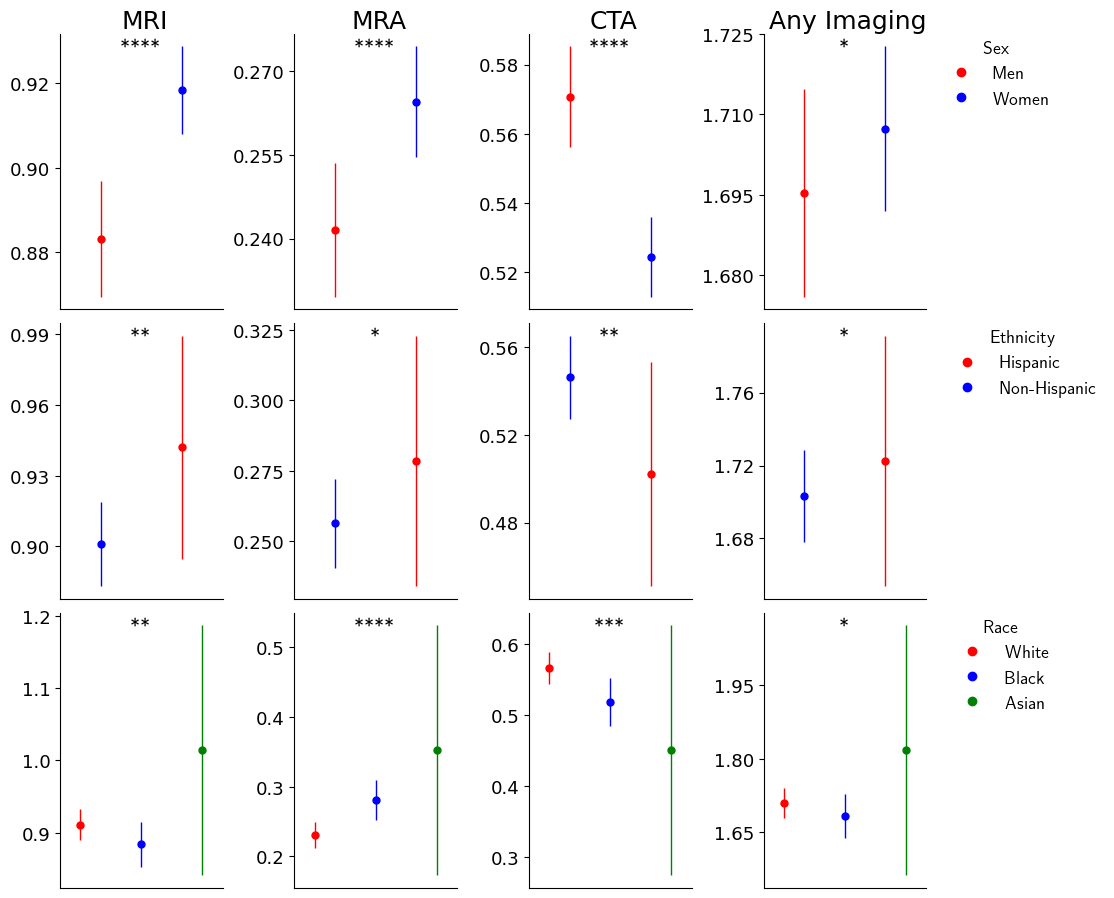

In [51]:
import scipy.stats as stats

fig, axs = plt.subplots(3, len(modality_names), figsize=(11, 9))

with plt.style.context(STYLE):
    for imod_, modality in enumerate(modality_names):
        col_ = 'sex'
        ax = axs[0,imod_]
        ax.set_title(modality, x=0.52, y=0.99, ha='center', fontsize=18)
        data_ = df_total[df_total['stroke']=='Ischemic']
        data_ = data_[['age_group',modality,col_]].dropna()
        data_ = data_.groupby(['sex','age_group'], observed=False).agg(['mean',lower_ci,upper_ci])
        data_.columns = ['mean','lower_ci','upper_ci']
        data_['up_yerr'] = data_['upper_ci']-data_['mean']
        data_['lo_yerr'] = data_['mean']-data_['lower_ci']
        # ax = sns.boxenplot(data_, x='age_group', y='MRI', hue=col_ ,ax=ax, palette=palette )
        y_ = data_.loc['Men','mean']
        x_ = np.array( [label_conv_dic[i_] for i_ in y_.index.to_list()] )
        ax.errorbar(x=x_-0.1, y=y_, yerr=data_.loc['Men'][['lo_yerr','lo_yerr']].values.T, color=clrs[0], marker='o', ms=5, ls='none')
    
        y_ = data_.loc['Women','mean']
        np.array( [label_conv_dic[i_] for i_ in y_.index.to_list()] )
        ax.errorbar(x=x_+0.1, y=y_, yerr=data_.loc['Women'][['lo_yerr','lo_yerr']].values.T, color=clrs[1], marker='o', ms=5, ls='none')

        def fun_(x):
            pv = get_pvalue(x[modality][x['sex'] == 'Men'], x[modality][x['sex'] == 'Women'])
            return give_star(pv)

        df_var = df_total[df_total['stroke']=='Ischemic']
        p_values = df_var.groupby('age_group', observed=False)[['sex',modality]].apply(lambda x: fun_(x))
        p_values = p_values.to_frame(name=modality).round(3)

        star_pos = 0.985
        if modality=='MRA': star_pos = 0.97
        for _,xi_ in enumerate(x_):
            ax.text(0.5,0.97,
                    p_values.iloc[_].values[0],
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        ax.set_xticks([])
        # ax.set_xticklabels([ f'${i_}$' for i_ in label_conv_dic.keys() ],rotation=45,ha='right', rotation_mode='anchor',fontsize=15)
        ax.yaxis.set_major_locator(plt.MaxNLocator(4,prune='both'))
        ax.set_yticks(ax.get_yticks())  # Set tick positions
        ax.set_yticklabels(ax.get_yticklabels(),rotation=0,ha='right', rotation_mode='anchor',fontsize=13)
        ax.set_ylabel('',fontsize=20)
        # ax.set_xlabel(modality,fontsize=15)
        # ax.yaxis.set_label_coords(-0.11, 0.5)
        ax.set_xlim(-0.2,.2)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
    plt.tight_layout()
    # Custom legend
    l0 = mlines.Line2D([], [], color=clrs[0], marker='o', linestyle='None', markersize=6, label='Blue Dot')
    l1 = mlines.Line2D([], [], color=clrs[1], marker='o', linestyle='None', markersize=6, label='Red Dot')
    handles = [l0,l1]
    ax.legend(handles, ['Men', 'Women'], title=col_.title(), fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(1.8, 1), borderaxespad=0.)

    for imod_, modality in enumerate(modality_names):
        col_ = 'ethnicity'
        ax = axs[1,imod_]

        # filter & drop unknown
        data_ = (
            df_total[df_total['stroke']=='Ischemic']
            .replace({'Unknown': np.nan})
            [[ 'age_group', modality, col_ ]]
            .dropna()
        )
        cset = ['Hispanic','Non-Hispanic'] #list(data_[col_].unique())

        # compute means and CIs
        data_ = (
            data_
            .groupby([col_, 'age_group'], observed=False)
            .agg(['mean', lower_ci, upper_ci])
        )
        data_.columns = ['mean', 'lower_ci', 'upper_ci']
        data_['up_yerr'] = data_['upper_ci'] - data_['mean']
        data_['lo_yerr'] = data_['mean'] - data_['lower_ci']

        # just errorbars, offset by ±0.1
        for i_, eth in enumerate(cset):
            dx = ((-1)**i_) * 0.1
            y_mean = data_.loc[eth, 'mean']
            x_vals = np.array([label_conv_dic[a] for a in y_mean.index])
            ax.errorbar(
                x_vals + dx,
                y_mean,
                yerr=data_.loc[eth][['lo_yerr','up_yerr']].values.T,
                color=clrs[i_],
                marker='o',
                ms=5,
                ls='none'
            )

        # p‐value stars between the two ethnicities
        def star_fn(x):
            g0 = x[x[col_]==cset[0]][modality]
            g1 = x[x[col_]==cset[1]][modality]
            return give_star(get_pvalue(g0, g1))

        pvals = (
            df_total[df_total['stroke']=='Ischemic']
            .groupby('age_group', observed=False)[[col_, modality]]
            .apply(lambda x: star_fn(x))
            .to_frame(name=modality)
            .round(3)
        )
        for idx, xpos in enumerate(x_vals):
            ax.text(0.5,0.97,
                    pvals.iloc[idx, 0],
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        # clean up axes
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune='both'))
        ax.tick_params(axis='y', labelsize=13)
        ax.set_ylabel('', fontsize=15)
        # ax.set_xlabel(modality, fontsize=15)
        ax.set_xlim(-0.2,.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # single legend
    handles = [
        mlines.Line2D([], [], color=clrs[i], marker='o', linestyle='None', markersize=6)
        for i in range(len(cset))
    ]
    ax.legend(
        handles, cset,
        title=col_.title(),
        fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(2.1, 1), borderaxespad=0.
    )
    plt.tight_layout()

    # save
    # name = f'per_age_group_{col_}_modalities'
    # for ext in ('pdf','svg','jpg'):
    #     fig.savefig(f'results/figs_young/{name}.{ext}',
    #                 dpi=(300 if ext=='jpg' else None))

    col_ = 'race'
    # fig, axs = plt.subplots(1, len(modality_names), figsize=(10, 3))
    coef_ = [-1, 0, 1]  # Adjust for different groups

    for imod_, modality in enumerate(modality_names):
        ax = axs[2,imod_]
        # filter to young ischemic & drop unknown
        data_ = (
            df_total[df_total['stroke']=='Ischemic']
            .replace({'Unknown': np.nan})
            [[ 'age_group', modality, col_ ]]
            .dropna()
        )
        cset = ['White','Black','Asian'] #list(data_[col_].unique())

        # aggregate mean + CIs
        data_ = (
            data_
            .groupby([col_, 'age_group'], observed=False)
            .agg(['mean', lower_ci, upper_ci])
        )
        data_.columns = ['mean','lower_ci','upper_ci']
        data_['up_yerr'] = data_['upper_ci'] - data_['mean']
        data_['lo_yerr'] = data_['mean'] - data_['lower_ci']

        # simple errorbars, offset by coef_
        for i_, group in enumerate(cset):
            dx = coef_[i_] * 0.15
            y_mean = data_.loc[group, 'mean']
            x_vals = np.array([label_conv_dic[a] for a in y_mean.index])
            ax.errorbar(
                x_vals + dx,
                y_mean,
                yerr=data_.loc[group][['lo_yerr','up_yerr']].values.T,
                color=clrs[i_],
                marker='o',
                ms=5,
                ls='none'
            )

        # Kruskal–Wallis across all race groups
        def kw_fn(x):
            groups = [ x[modality][x[col_]==g] for g in cset ]
            _, p = stats.kruskal(*groups)
            return give_star(p)

        pvals = (
            df_total[df_total['stroke']=='Ischemic']
            .groupby('age_group', observed=False)[[col_, modality]]
            .apply(lambda x: kw_fn(x))
            .to_frame(name=modality)
            .round(3)
        )
        # annotate stars
        for idx, xpos in enumerate(x_vals):
            ax.text(0.5,0.97,
                    pvals.iloc[idx, 0],
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        # clean styling
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune='both'))
        ax.tick_params(axis='y', labelsize=13)
        ax.set_ylabel('', fontsize=15)
        # ax.set_xlabel(modality, fontsize=15)
        ax.set_xlim(-0.2,.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # single legend
    handles = [
        mlines.Line2D([], [], color=clrs[i], marker='o', linestyle='None', markersize=6)
        for i in range(len(cset))
    ]
    ax.legend(
        handles, cset,
        title=col_.title(),
        fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(1.8, 1), borderaxespad=0.
    )
    plt.tight_layout()

    # save all formats
    name = f'per_age_group_ethnicity_race_modalities'
    for ext in ('pdf','svg','jpg'):
        fig.savefig(
            f'results/figs_young/{name}.{ext}',
            dpi=(300 if ext=='jpg' else None)
        )


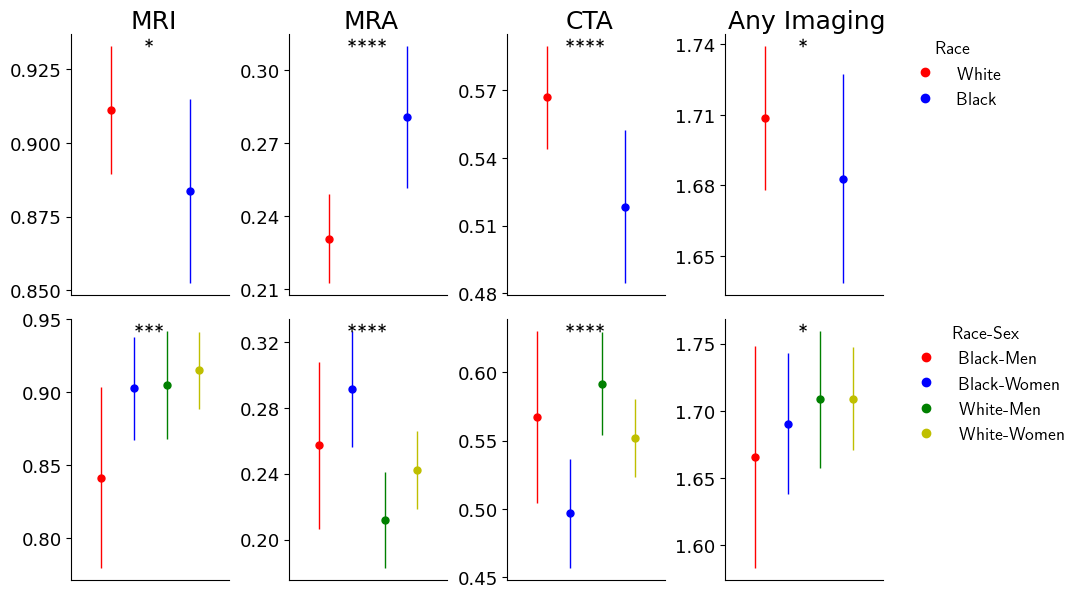

In [52]:
col_ = 'race'
fig, axs = plt.subplots(2, len(modality_names), figsize=(11, 6))

with plt.style.context(STYLE):
    for imod_, modality in enumerate(modality_names):
        ax = axs[0,imod_]
        ax.set_title(modality, x=0.52, y=0.99, ha='center', fontsize=18)
        # filter to young ischemic, drop Unknown & Asian
        data_ = (
            df_total[df_total['stroke']=='Ischemic']
            .replace({'Unknown': np.nan, 'Asian': np.nan})
            [['age_group', modality, col_]]
            .dropna()
        )
        cset = ['White','Black'] #list(data_[col_].unique())  # should now be two races

        # aggregate mean + CIs
        data_ = (
            data_
            .groupby([col_, 'age_group'], observed=False)
            .agg(['mean', lower_ci, upper_ci])
        )
        data_.columns = ['mean','lower_ci','upper_ci']
        data_['up_yerr'] = data_['upper_ci'] - data_['mean']
        data_['lo_yerr'] = data_['mean'] - data_['lower_ci']

        # simple errorbars, offset by ±0.1
        for i_, group in enumerate(cset):
            dx = -((-1)**i_) * 0.1
            y_mean = data_.loc[group, 'mean']
            x_vals = np.array([label_conv_dic[a] for a in y_mean.index])
            ax.errorbar(
                x_vals + dx,
                y_mean,
                yerr=data_.loc[group][['lo_yerr','up_yerr']].values.T,
                color=clrs[i_],
                marker='o',
                ms=5,
                ls='none'
            )

        # pairwise p-value stars between the two races
        def star_fn(x):
            g0 = x[x[col_]==cset[0]][modality]
            g1 = x[x[col_]==cset[1]][modality]
            return give_star(get_pvalue(g0, g1))

        pvals = (
            df_total[df_total['stroke']=='Ischemic']
            .groupby('age_group', observed=False)[[col_, modality]]
            .apply(lambda x: star_fn(x))
            .to_frame(name=modality)
            .round(3)
        )
        for idx, xpos in enumerate(x_vals):
            ax.text(0.5,0.97,
                    pvals.iloc[idx, 0],
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        # styling
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune='both'))
        ax.tick_params(axis='y', labelsize=13)
        ax.set_ylabel('', fontsize=15)
        # ax.set_xlabel(modality, fontsize=15)
        ax.set_xlim(-0.2,.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # single legend
    handles = [
        mlines.Line2D([], [], color=clrs[i], marker='o', linestyle='None', markersize=6)
        for i in range(len(cset))
    ]
    ax.legend(
        handles, cset,
        title=col_.title(),
        fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(1.8, 1), borderaxespad=0.
    )
    plt.tight_layout()

    col_  = 'race-sex'
    coef_ = [-0.75, -0.25, 0.25, 0.75]
    cset  = ['Black-Men','Black-Women','White-Men','White-Women']

# fig, axs = plt.subplots(1, len(modality_names), figsize=(12, 3))
# with plt.style.context(STYLE):
    for imod_, modality in enumerate(modality_names):
        ax = axs[1,imod_]
        # ax.set_title(modality, fontsize=16, pad=8)

        # filter to young ischemic, drop Unknown
        data_ = (
            df_total[df_total['stroke']=='Ischemic']
            .replace({'Unknown': np.nan})
            [['age_group', modality, col_]]
            .dropna()
        )

        # aggregate mean + CIs
        data_ = (
            data_
            .groupby([col_, 'age_group'], observed=False)
            .agg(['mean', lower_ci, upper_ci])
        )
        data_.columns = ['mean','lower_ci','upper_ci']
        data_['up_yerr'] = data_['upper_ci'] - data_['mean']
        data_['lo_yerr'] = data_['mean'] - data_['lower_ci']

        # plot errorbars for each race-sex group
        for i_, grp in enumerate(cset):
            dx     = coef_[i_] * 0.1
            y_mean = data_.loc[grp, 'mean']
            x_vals = np.array([label_conv_dic[a] for a in y_mean.index])

            ax.errorbar(
                x_vals + dx,
                y_mean,
                yerr=data_.loc[grp][['lo_yerr','up_yerr']].values.T,
                color=clrs[i_], marker='o', ms=5, ls='none'
            )

        # Kruskal–Wallis across the four groups
        def kw_fn(x):
            groups = [ x[modality][x[col_]==g] for g in cset ]
            _, p = stats.kruskal(*groups)
            return give_star(p)

        pvals = (
            df_total[df_total['stroke']=='Ischemic']
            .groupby('age_group', observed=False)[[col_, modality]]
            .apply(kw_fn)
            .to_frame(name=modality)
            .round(3)
        )

        # annotate stars
        for idx, xpos in enumerate(x_vals):
            ax.text(0.5,0.97,
                    pvals.iloc[idx, 0],
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        # clean styling
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune='both'))
        ax.tick_params(axis='y', labelsize=13)
        ax.set_ylabel('', fontsize=15)
        # ax.set_xlabel(modality, fontsize=15)
        ax.set_xlim(-0.12,.12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # single legend
    handles = [
        mlines.Line2D([], [], color=clrs[i], marker='o', linestyle='None', markersize=6)
        for i in range(len(cset))
    ]
    ax.legend(
        handles, cset,
        title=col_.title(),
        fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(2.2, 1), borderaxespad=0.
    )
    plt.tight_layout()

    # save all formats
    name = f'per_age_group_BW_race-sex_modalities'
    for ext in ('pdf','svg','jpg'):
        fig.savefig(
            f'results/figs_young/{name}.{ext}',
            dpi=(300 if ext=='jpg' else None)
        )


# Analysis

In [53]:
df_total.head(3)

,patient_id,CTA,MRA,MRI,sex,race,ethnicity,year_of_birth,postal_code,age@stroke,dx_year,stroke,CHA2DS2_VASc_score,age_group,Any Imaging,race-sex
0,#A#YD,1,0,1,Women,Unknown,Unknown,1969.0,347,49.0,2018,Ischemic,2,19<,2,<NA>
1,#A14C,0,0,1,Women,Unknown,Unknown,1975.0,776,43.0,2018,Ischemic,2,19<,1,<NA>
2,#A3DD,0,0,1,Women,Unknown,Unknown,1988.0,461,30.0,2018,Ischemic,1,19<,1,<NA>


In [54]:
from scipy.stats import chi2_contingency

# Define groups and MRI columns
groups = ['sex', 'race', 'ethnicity', 'dx_year'] #'age@stroke', 
columns = ['wo/MRI', 'w/MRI']

# Initialize result dataframe
result_df = pd.DataFrame(columns=['Group'] + columns + ['p-value'])

# Function to calculate within-row percentages
def row_percent(counts):
    total = counts.sum()
    return (counts / total * 100).round(2)

# Iterate over each group
for group in groups:
    # Insert header row for group
    result_df = pd.concat([result_df, pd.DataFrame({'Group': [group]})], ignore_index=True)
    
    unique_values = df_total[group].dropna().unique()

    for value in unique_values:
        row = {'Group': str(value)}
        
        df_filtered = df_total[df_total[group] == value]
        count_0 = (df_filtered['MRI'] == 0).sum()
        count_1 = (df_filtered['MRI'] != 0).sum()
        counts = pd.Series([count_0, count_1], index=['wo/MRI', 'w/MRI'])

        # Get percentages that sum to 100%
        percents = row_percent(counts)

        # Format as "N (P%)"
        row['wo/MRI'] = f"{count_0} ({percents['wo/MRI']}%)"
        row['w/MRI'] = f"{count_1} ({percents['w/MRI']}%)"

        # Compute chi-square p-value (current value vs rest)
        df_group = df_total[[group, 'MRI']].dropna()
        table = pd.crosstab(df_group[group] == value, df_group['MRI'] != 0)
        try:
            _, p, _, _ = chi2_contingency(table)
            row['p-value'] = f"{p:.4f}"
        except ValueError:
            row['p-value'] = "NA"

        result_df = pd.concat([result_df, pd.DataFrame([row])], ignore_index=True)

# Save to docx
to_docx(result_df, f'results/tables_young/summary_table_MRI.docx')

In [55]:
df_total.columns

Index(['patient_id', 'CTA', 'MRA', 'MRI', 'sex', 'race', 'ethnicity',
       'year_of_birth', 'postal_code', 'age@stroke', 'dx_year', 'stroke',
       'CHA2DS2_VASc_score', 'age_group', 'Any Imaging', 'race-sex'],
      dtype='object')

In [56]:
modality_names

['MRI', 'MRA', 'CTA', 'Any Imaging']

In [57]:
# Selecting relevant columns
df_var = df_total[['stroke','age_group']+modality_names].dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke','age_group']).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[2:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
# agg_df = agg_df.reset_index()
agg_df

/tmp/ipykernel_935986/3206734425.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df_var.groupby(['stroke','age_group']).agg(["mean",lower_ci,upper_ci])


,,MRI,MRA,CTA,Any Imaging
stroke,age_group,,,,
Ischemic,19<,0.9 (0.9 - 0.9),0.3 (0.2 - 0.3),0.5 (0.5 - 0.6),1.7 (1.7 - 1.7)


## Table 3, results for mean and CI comparision base on sex

In [58]:
col_ = 'sex'
# Selecting relevant columns
df_var = df_total[['stroke', 'dx_year', col_]+modality_names].dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', 'dx_year', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[3:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
agg_df = agg_df.reset_index()
to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,dx_year,sex,MRI,MRA,CTA,Any Imaging
0,Ischemic,2018,Men,0.9 (0.9 - 0.9),0.3 (0.2 - 0.3),0.5 (0.5 - 0.6),1.7 (1.7 - 1.7)
1,Ischemic,2018,Women,0.9 (0.9 - 1.0),0.3 (0.3 - 0.3),0.5 (0.5 - 0.5),1.7 (1.7 - 1.7)
2,Ischemic,2019,Men,0.9 (0.8 - 0.9),0.2 (0.2 - 0.2),0.6 (0.6 - 0.6),1.7 (1.7 - 1.7)
3,Ischemic,2019,Women,0.9 (0.9 - 0.9),0.2 (0.2 - 0.3),0.6 (0.6 - 0.6),1.7 (1.7 - 1.7)


In [59]:
col_ = 'sex'
# Selecting relevant columns
df_var = df_total[['stroke', col_]+modality_names].dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[2:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
agg_df = agg_df.reset_index()
# to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,sex,MRI,MRA,CTA,Any Imaging
0,Ischemic,Men,0.9 (0.9 - 0.9),0.2 (0.2 - 0.3),0.6 (0.6 - 0.6),1.7 (1.7 - 1.7)
1,Ischemic,Women,0.9 (0.9 - 0.9),0.3 (0.3 - 0.3),0.5 (0.5 - 0.5),1.7 (1.7 - 1.7)


## Table 4, results for Pvalue comparision base on sex

In [60]:
df_var.columns[2:]

Index(['MRI', 'MRA', 'CTA', 'Any Imaging'], dtype='object')

In [61]:
col_ = 'sex'
df_pvs = []
for col in df_var.columns[2:]:
    p_values = df_var.groupby(['stroke'])[[col_,col]].apply(lambda x: get_pvalue(x[col][x['sex'] == 'Men'], x[col][x['sex'] == 'Women']))
    df_pvs.append(p_values.to_frame(name=col).round(3))
    # agg_df[f'{col}_p_value'] = p_values.values
agg_df = pd.concat(df_pvs,axis=1)
# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
agg_df = agg_df.reset_index()
name = f'{col_}_pv'
to_docx(agg_df,f'results/tables_young/disparity_age-{name}.docx')
agg_df

,stroke,MRI,MRA,CTA,Any Imaging
0,Ischemic,0.0,0.0,0.0,0.064


## Table 5, results for mean and CI comparision base on Ethnicity

In [62]:
col_ = 'ethnicity'
# Selecting relevant columns
df_var = df_total[['stroke', 'dx_year', col_]+modality_names].replace({'Unknown':np.nan}).dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', 'dx_year', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[3:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
agg_df = agg_df.reset_index()
to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,dx_year,ethnicity,MRI,MRA,CTA,Any Imaging
0,Ischemic,2018,Hispanic,1.0 (0.9 - 1.0),0.3 (0.2 - 0.4),0.5 (0.4 - 0.5),1.7 (1.6 - 1.8)
1,Ischemic,2018,Non-Hispanic,0.9 (0.9 - 0.9),0.3 (0.3 - 0.3),0.5 (0.5 - 0.5),1.7 (1.7 - 1.7)
2,Ischemic,2019,Hispanic,0.9 (0.8 - 1.0),0.3 (0.2 - 0.3),0.5 (0.5 - 0.6),1.7 (1.6 - 1.8)
3,Ischemic,2019,Non-Hispanic,0.9 (0.9 - 0.9),0.2 (0.2 - 0.3),0.6 (0.6 - 0.6),1.7 (1.7 - 1.7)


In [63]:
col_ = 'ethnicity'
# Selecting relevant columns
df_var = df_total[['stroke', col_]+modality_names].replace({'Unknown':np.nan}).dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[2:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
agg_df = agg_df.reset_index()
# to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,ethnicity,MRI,MRA,CTA,Any Imaging
0,Ischemic,Hispanic,0.9 (0.9 - 1.0),0.3 (0.2 - 0.3),0.5 (0.5 - 0.6),1.7 (1.7 - 1.8)
1,Ischemic,Non-Hispanic,0.9 (0.9 - 0.9),0.3 (0.2 - 0.3),0.5 (0.5 - 0.6),1.7 (1.7 - 1.7)


## Table 6, results for Pvalue comparision base on Ethnicity

In [64]:
df_pvs = []
for col in df_var.columns[2:]:
    p_values = df_var.groupby(['stroke'])[[col_,col]].apply(lambda x: get_pvalue(x[col][x[col_] == 'Hispanic'], x[col][x[col_] == 'Non-Hispanic']))
    df_pvs.append(p_values.to_frame(name=col).round(3))
    # agg_df[f'{col}_p_value'] = p_values.values
agg_df = pd.concat(df_pvs,axis=1)
# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
agg_df = agg_df.reset_index()
name = f'{col_}_pv'
to_docx(agg_df,f'results/tables_young/disparity_age-{name}.docx')
agg_df

,stroke,MRI,MRA,CTA,Any Imaging
0,Ischemic,0.014,0.141,0.019,0.371


## Table 7, results for mean and CI comparision base on race

In [65]:
col_ = 'race'
# Selecting relevant columns
df_var = df_total[['stroke', 'dx_year', col_]+modality_names].replace({'Unknown':np.nan}).dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', 'dx_year', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[3:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
if col_=='race':
    agg_df = agg_df.loc[(['Ischemic'],[2018,2019],['White','Black','Asian'])]
agg_df = agg_df.reset_index()
to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,dx_year,race,MRI,MRA,CTA,Any Imaging
0,Ischemic,2018,White,0.9 (0.9 - 1.0),0.3 (0.2 - 0.3),0.5 (0.5 - 0.6),1.7 (1.7 - 1.8)
1,Ischemic,2018,Black,0.9 (0.8 - 0.9),0.3 (0.3 - 0.3),0.5 (0.4 - 0.5),1.7 (1.6 - 1.7)
2,Ischemic,2018,Asian,1.0 (0.8 - 1.3),0.4 (0.1 - 0.7),0.4 (0.2 - 0.7),1.9 (1.5 - 2.2)
3,Ischemic,2019,White,0.9 (0.9 - 0.9),0.2 (0.2 - 0.2),0.6 (0.6 - 0.6),1.7 (1.7 - 1.7)
4,Ischemic,2019,Black,0.9 (0.8 - 0.9),0.3 (0.2 - 0.3),0.6 (0.5 - 0.6),1.7 (1.6 - 1.8)
5,Ischemic,2019,Asian,1.0 (0.8 - 1.2),0.3 (0.1 - 0.6),0.5 (0.2 - 0.7),1.8 (1.4 - 2.1)


In [66]:
col_ = 'race'
# Selecting relevant columns
df_var = df_total[['stroke', col_]+modality_names].replace({'Unknown':np.nan}).dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[2:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]
if col_=='race':
    agg_df = agg_df.loc[(['Ischemic'],['White','Black','Asian']),:]
agg_df = agg_df.reset_index()
# to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,race,MRI,MRA,CTA,Any Imaging
0,Ischemic,White,0.9 (0.9 - 0.9),0.2 (0.2 - 0.2),0.6 (0.5 - 0.6),1.7 (1.7 - 1.7)
1,Ischemic,Black,0.9 (0.9 - 0.9),0.3 (0.3 - 0.3),0.5 (0.5 - 0.6),1.7 (1.6 - 1.7)
2,Ischemic,Asian,1.0 (0.8 - 1.2),0.4 (0.2 - 0.5),0.5 (0.3 - 0.6),1.8 (1.6 - 2.1)


In [67]:
df_pvs = []
for col in df_var.columns[3:]:
    cset = list(df_var[col_].unique())
    # Perform Kruskal-Wallis test for multi-group comparison
    def kruskal_test(x):
        # Apply Kruskal-Wallis test across all groups
        groups = [x[col][x[col_] == group] for group in cset]
        stat, p_value = stats.kruskal(*groups)
        return p_value  # Function to format the significance
    
    p_values = df_var.groupby(['stroke'])[[col_,col]]
    p_values = p_values.apply(lambda x: kruskal_test(x))
    df_pvs.append(p_values.to_frame(name=col).round(3))
    # agg_df[f'{col}_p_value'] = p_values.values
print(cset)
agg_df = pd.concat(df_pvs,axis=1)
agg_df = agg_df.reset_index()
name = f'{col_}_pv'
to_docx(agg_df,f'results/tables_young/disparity_age-{name}.docx')
agg_df

['Black', 'White', 'Asian']


,stroke,MRA,CTA,Any Imaging
0,Ischemic,0.0,0.001,0.237


## Table 9, results for Pvalue comparision base on race, black vr white

In [68]:
comp_groups = ['Black','White']
comp_col = 'race'

df_pvs = []
for col in df_var.columns[2:]:
    p_values = df_var.groupby(['stroke'])[['race',col]].apply(lambda x: get_pvalue(x[col][x[comp_col] == comp_groups[0]], x[col][x[comp_col] == comp_groups[1]]))
    df_pvs.append(p_values.to_frame(name=col).round(3))
    # agg_df[f'{col}_p_value'] = p_values.values
print(comp_groups)
agg_df = pd.concat(df_pvs,axis=1)
agg_df = agg_df.reset_index()
name = f'{col_}_BW_pv'
to_docx(agg_df,f'results/tables_young/disparity_age-{name}.docx')
agg_df

['Black', 'White']


,stroke,MRI,MRA,CTA,Any Imaging
0,Ischemic,0.062,0.0,0.001,0.382


In [69]:
col_ = 'race-sex'
# Selecting relevant columns
df_var = df_total[['stroke', col_]+modality_names].replace({'Unknown':np.nan}).dropna()
    
# Aggregating mean and 68% CI
agg_df = df_var.groupby(['stroke', col_]).agg(["mean",lower_ci,upper_ci])

# Flattening the MultiIndex columns
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Formatting the results
for col in df_var.columns[2:]:
    agg_df[f'{col}_formatted'] = agg_df.apply(lambda row: f"{row[f'{col}_mean']:.1f} ({row[f'{col}_lower_ci']:.1f} - {row[f'{col}_upper_ci']:.1f})", axis=1)

# Dropping the original mean and ci_68 columns
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if not col.endswith('_formatted')])

agg_df.columns = [i.replace('_formatted','') for i in agg_df.columns]

# agg_df = agg_df.loc[(['Ischemic','Hemorrhagic'])]

agg_df = agg_df.reset_index()
to_docx(agg_df,f'results/tables_young/disparity_age-{col_}.docx')
agg_df

,stroke,race-sex,MRI,MRA,CTA,Any Imaging
0,Ischemic,Black-Men,0.8 (0.8 - 0.9),0.3 (0.2 - 0.3),0.6 (0.5 - 0.6),1.7 (1.6 - 1.7)
1,Ischemic,Black-Women,0.9 (0.9 - 0.9),0.3 (0.3 - 0.3),0.5 (0.5 - 0.5),1.7 (1.6 - 1.7)
2,Ischemic,White-Men,0.9 (0.9 - 0.9),0.2 (0.2 - 0.2),0.6 (0.6 - 0.6),1.7 (1.7 - 1.8)
3,Ischemic,White-Women,0.9 (0.9 - 0.9),0.2 (0.2 - 0.3),0.6 (0.5 - 0.6),1.7 (1.7 - 1.7)


## Table 8, results for Pvalue comparision base on race

In [70]:
df_pvs = []
for col in df_var.columns[3:]:
    cset = list(df_var[col_].unique())
    # Perform Kruskal-Wallis test for multi-group comparison
    def kruskal_test(x):
        # Apply Kruskal-Wallis test across all groups
        groups = [x[col][x[col_] == group] for group in cset]
        stat, p_value = stats.kruskal(*groups)
        return p_value  # Function to format the significance
    
    p_values = df_var.groupby(['stroke'])[[col_,col]]
    p_values = p_values.apply(lambda x: kruskal_test(x))
    df_pvs.append(p_values.to_frame(name=col).round(3))
    # agg_df[f'{col}_p_value'] = p_values.values
print(cset)
agg_df = pd.concat(df_pvs,axis=1)
agg_df = agg_df.reset_index()
name = f'{col_}_pv'
to_docx(agg_df,f'results/tables_young/disparity_age-{name}.docx')
agg_df

['Black-Women', 'White-Men', 'White-Women', 'Black-Men']


,stroke,MRA,CTA,Any Imaging
0,Ischemic,0.0,0.0,0.556


# Pvalue test between groups in general and adjusted Regression analysis to validate the earlier results

In [74]:
results = []

for df___,stroke_ in zip( [df_total], ['Ischemic'] ):
    df__ = df___.copy(deep=True)
    df__.loc[:, 'Any Imaging'] = df__[[ 'MRI', 'CTA', 'MRA']].sum(axis=1)
    df__['age_at_stroke'] = df__['age@stroke']
    for col_ in modality_names:

        data_ = df__[[col_,'sex','age_at_stroke','ethnicity', 'race','CHA2DS2_VASc_score']].rename(columns={col_:col_.replace(' ','_')})
        data_ = data_.replace({'Unknown': np.nan})
        data_['race'] = data_['race'].astype('category')
        data_['race'] = data_['race'].cat.reorder_categories(['White', 'Black', 'Asian'], ordered=False)
        col__ = col_.replace(' ','_')
        data_['sex'] = (data_['sex']=='Men').astype(float)
        data_['ethnicity'] = (data_['ethnicity']=='Hispanic').astype(float)
        data_ = data_.dropna()
        model_sex_age_race_CVS = smf.ols(f'{col__} ~ sex + ethnicity + age_at_stroke + C(race) + CHA2DS2_VASc_score', data=data_).fit()

        sex_p = f"{model_sex_age_race_CVS.pvalues['sex']:.2f}" if model_sex_age_race_CVS.pvalues['sex']>=0.05 else '≤0.05'
        age_p = f"{model_sex_age_race_CVS.pvalues['age_at_stroke']:.3f}" if model_sex_age_race_CVS.pvalues['age_at_stroke']>=0.001 else 'p≤0.001'
        eth_p = f"{model_sex_age_race_CVS.pvalues['ethnicity']:.2f}" if model_sex_age_race_CVS.pvalues['ethnicity']>=0.05 else '≤0.05'
        blk_p = f"{model_sex_age_race_CVS.pvalues['C(race)[T.Black]']:.2f}" if model_sex_age_race_CVS.pvalues['C(race)[T.Black]']>=0.05 else '≤0.05'
        asi_p = f"{model_sex_age_race_CVS.pvalues['C(race)[T.Asian]']:.2f}" if model_sex_age_race_CVS.pvalues['C(race)[T.Asian]']>=0.05 else '≤0.05'
        cvs_p = f"{model_sex_age_race_CVS.pvalues['CHA2DS2_VASc_score']:.2f}" if model_sex_age_race_CVS.pvalues['CHA2DS2_VASc_score']>=0.05 else '≤0.05'
        results.append({
            'Modality': col_,
            'Sex': f"{model_sex_age_race_CVS.params['sex']:.2f} ({model_sex_age_race_CVS.conf_int().loc['sex'][0]:.2f}, {model_sex_age_race_CVS.conf_int().loc['sex'][1]:.2f}; {sex_p})",
            'Age': f"{model_sex_age_race_CVS.params['age_at_stroke']:.2f} ({model_sex_age_race_CVS.conf_int().loc['age_at_stroke'][0]:.2f}, {model_sex_age_race_CVS.conf_int().loc['age_at_stroke'][1]:.2f}; {age_p})",
            'Ethnicity': f"{model_sex_age_race_CVS.params['ethnicity']:.2f} ({model_sex_age_race_CVS.conf_int().loc['ethnicity'][0]:.2f}, {model_sex_age_race_CVS.conf_int().loc['ethnicity'][1]:.2f}; {eth_p})",
            'Black': f"{model_sex_age_race_CVS.params.get('C(race)[T.Black]', np.nan):.2f} ({model_sex_age_race_CVS.conf_int().loc['C(race)[T.Black]'][0]:.2f}, {model_sex_age_race_CVS.conf_int().loc['C(race)[T.Black]'][1]:.2f}; {blk_p})",
            'Asian': f"{model_sex_age_race_CVS.params.get('C(race)[T.Asian]', np.nan):.2f} ({model_sex_age_race_CVS.conf_int().loc['C(race)[T.Asian]'][0]:.2f}, {model_sex_age_race_CVS.conf_int().loc['C(race)[T.Asian]'][1]:.2f}; {asi_p})",
            'CVS': f"{model_sex_age_race_CVS.params['CHA2DS2_VASc_score']:.2f} ({model_sex_age_race_CVS.conf_int().loc['CHA2DS2_VASc_score'][0]:.2f}, {model_sex_age_race_CVS.conf_int().loc['CHA2DS2_VASc_score'][1]:.2f}; {cvs_p})",
        })

# Convert results to DataFrame and save as CSV
# results_df = pd.DataFrame(results)
# to_docx(results_df,f'results/tables_young/disparity_age-overal and regression.docx')

results_df = pd.DataFrame(results)
results_df_ = results_df.set_index('Modality',drop=1).T.reset_index()
to_docx(results_df_,f'results/tables_young/disparity_age-overal and regression.docx')

results_df_

Modality,index,MRI,MRA,CTA,Any Imaging
0,Sex,"-0.07 (-0.10, -0.03; ≤0.05)","-0.05 (-0.08, -0.02; ≤0.05)","0.05 (0.01, 0.08; ≤0.05)","-0.07 (-0.11, -0.02; ≤0.05)"
1,Age,"0.00 (-0.00, 0.00; 0.275)","-0.00 (-0.00, 0.00; 0.709)","-0.00 (-0.00, 0.00; 0.589)","0.00 (-0.00, 0.00; 0.891)"
2,Ethnicity,"0.05 (-0.00, 0.11; 0.06)","0.02 (-0.03, 0.07; 0.36)","-0.08 (-0.14, -0.02; ≤0.05)","-0.00 (-0.08, 0.07; 0.94)"
3,Black,"-0.02 (-0.05, 0.01; 0.21)","0.05 (0.02, 0.07; ≤0.05)","-0.06 (-0.09, -0.03; ≤0.05)","-0.03 (-0.07, 0.01; 0.14)"
4,Asian,"0.12 (-0.01, 0.25; 0.08)","0.17 (0.06, 0.29; ≤0.05)","-0.18 (-0.32, -0.04; ≤0.05)","0.11 (-0.07, 0.30; 0.23)"
5,CVS,"-0.04 (-0.06, -0.02; ≤0.05)","-0.01 (-0.03, 0.01; 0.39)","-0.01 (-0.03, 0.02; 0.59)","-0.05 (-0.08, -0.02; ≤0.05)"


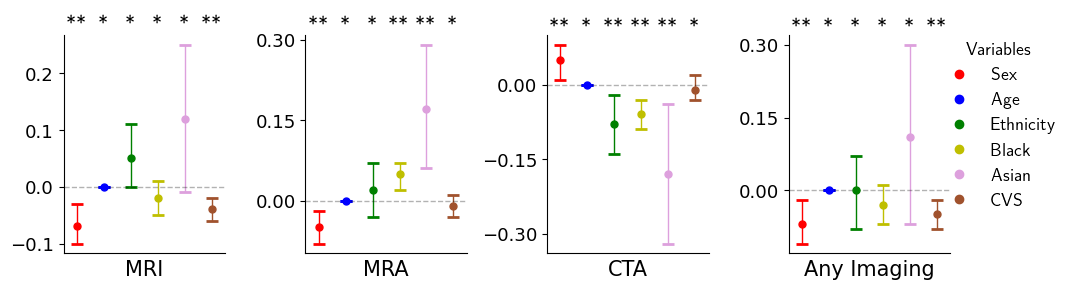

In [75]:
# Updated plotting code to match your style with legend
import re

# Set up styling variables
STYLE = ['science', 'nature']
clrs = ['r', 'b', 'g', 'y', 'plum', 'sienna', 'darkolivegreen']

def parse_coef_string(coef_string):
    """Parse coefficient string to extract coefficient, lower_ci, upper_ci, and p-value"""
    pattern = r'([+-]?\d*\.?\d+)\s*\(([+-]?\d*\.?\d+),\s*([+-]?\d*\.?\d+);\s*([^)]+)\)'
    match = re.match(pattern, coef_string)
    
    if match:
        coef = float(match.group(1))
        lower_ci = float(match.group(2))
        upper_ci = float(match.group(3))
        p_value_str = match.group(4).strip()
        
        if p_value_str == '≤0.05':
            p_value = 0.05
        else:
            p_value = float(p_value_str)
        
        return coef, lower_ci, upper_ci, p_value
    else:
        return None, None, None, None

# Parse the results_df data
parsed_data = {}
for col in ['Sex', 'Age', 'Ethnicity', 'Black', 'Asian', 'CVS']:
    parsed_data[col] = {}
    for idx, row in results_df.iterrows():
        modality = row['Modality']
        coef, lower_ci, upper_ci, p_value = parse_coef_string(row[col])
        
        if coef is not None:
            parsed_data[col][modality] = {
                'coef': coef,
                'lower_ci': lower_ci,
                'upper_ci': upper_ci,
                'p_value': p_value,
                'up_yerr': upper_ci - coef,
                'lo_yerr': coef - lower_ci,
                'star': give_star(p_value)
            }

# Create figure matching your style
fig, axs = plt.subplots(1, len(results_df), figsize=(11, 3))
modality_names = results_df['Modality'].tolist()

# Define variables and their positions/colors
variables = ['Sex', 'Age', 'Ethnicity', 'Black', 'Asian', 'CVS']
variable_colors = [0, 1, 2, 3, 4, 5]

# Define x-positions with reduced spacing (similar to your other plots)
x_positions = np.linspace(-1,1,len(variables)) #[-0.8, -0.4, 0, 0.4, 0.8]  # Centered around 0

with plt.style.context(STYLE):
    for imod, modality in enumerate(modality_names):
        ax = axs[imod]
        
        # Find maximum coefficient for consistent star positioning
        max_coef = -np.inf
        for var in variables:
            if var in parsed_data and modality in parsed_data[var]:
                data = parsed_data[var][modality]
                max_coef = max(max_coef, data['coef'] + data['up_yerr'])
        
        star_height = max_coef + 0.03  # Fixed height for all stars
        
        # Plot each variable
        for i, var in enumerate(variables):
            if var in parsed_data and modality in parsed_data[var]:
                data = parsed_data[var][modality]
                
                # Plot error bar
                ax.errorbar(
                    x_positions[i],
                    data['coef'],
                    yerr=[[data['lo_yerr']], [data['up_yerr']]],
                    color=clrs[variable_colors[i]],
                    marker='o',
                    ms=5,  # Match marker size from your other plots
                    ls='none',
                    capsize=4,
                    capthick=2
                )
                
                # Add p-value star at consistent height
                ax.text(
                    x_positions[i],
                    star_height,
                    data['star'],
                    fontsize=15,  # Match font size from your other plots
                    ha='center',
                    va='bottom'
                )
        
        # Set axis properties to match your style
        ax.set_xticks([])  # Remove x-ticks as requested
        ax.set_xlim(-1.2, 1.2)  # Adjust limits to accommodate all points
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
        ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune='both'))
        ax.tick_params(axis='y', labelsize=13)
        ax.set_ylabel('', fontsize=15)
        ax.set_xlabel(modality, fontsize=15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Create legend similar to your other plots
    handles = [
        mlines.Line2D([], [], color=clrs[i], marker='o', linestyle='None', markersize=6)
        for i in range(len(variables))
    ]
    ax.legend(
        handles, variables,
        title='Variables',
        fontsize=13, title_fontsize='13', loc='upper right', 
        bbox_to_anchor=(1.7, 1), borderaxespad=0.
    )

plt.tight_layout()

# Save all formats
name = f'Regression_results'
for ext in ('pdf','svg','jpg'):
    fig.savefig(
        f'results/figs_young/{name}.{ext}',
        dpi=(300 if ext=='jpg' else None)
    )

# NIS results

In [76]:
df_total_NIS = pd.read_csv('./NIS_results/MRI_CT_Summary_with_pvalues.csv')
# df_total_NIS['sex'] = df_total_NIS['sex'].replace({'Male':'Men','Female':'Women'})

col_ = 'sex'

df_total_NIS[col_] = df_total_NIS['FEMALE'].replace({
    0:'Men',
    1:'Women'
})

cset = ['Men','Women']


df_total_NIS['age_group'] = df_total_NIS['Age_Stratified'].replace(
    {j+1:i for i,j in label_conv_dic.items()}
)
df_total_NIS = df_total_NIS[ (df_total_NIS['age_group']=='19<') & (df_total_NIS['DiseaseType']=='Ischemic')]

In [77]:
# df_total_NIS[['DiseaseType','age_group','sex','Mean_MRI','MRI_Lower_CI',
#               'MRI_Upper_CI','Mean_CT','CT_Lower_CI','CT_Upper_CI',
#               'MRI_p-value','CT_p-value']]#.head(5)
df_total_NIS[['DiseaseType','age_group','sex','Mean_MRI','MRI_Lower_CI',
              'MRI_Upper_CI','MRI_p-value']]

,DiseaseType,age_group,sex,Mean_MRI,MRI_Lower_CI,MRI_Upper_CI,MRI_p-value
2,Ischemic,19<,Men,0.804123,0.760371,0.847876,0.008468
3,Ischemic,19<,Women,0.894119,0.843346,0.944891,0.008468


In [78]:
df_total_NIS = pd.read_csv('./NIS_results/MRI_CT_Race_Summary_with_pvalues.csv')
df_total_NIS

col_ = 'race'

df_total_NIS[col_] = df_total_NIS['RACE']

cset = ['White','Black']

df_total_NIS['age_group'] = df_total_NIS['Age_Stratified'].replace(
    {j+1:i for i,j in label_conv_dic.items()}
)
df_total_NIS = df_total_NIS[ (df_total_NIS['age_group']=='19<') & (df_total_NIS['DiseaseType']=='Ischemic')]

In [79]:
# df_total_NIS[['DiseaseType','age_group','race','Mean_MRI','MRI_Lower_CI',
#               'MRI_Upper_CI','Mean_CT','CT_Lower_CI','CT_Upper_CI',
#               'MRI_p-value','CT_p-value']]
df_total_NIS[['DiseaseType','age_group','race','Mean_MRI','MRI_Lower_CI',
              'MRI_Upper_CI','MRI_p-value']]

,DiseaseType,age_group,race,Mean_MRI,MRI_Lower_CI,MRI_Upper_CI,MRI_p-value
2,Ischemic,19<,White,0.750001,0.698940,0.801062,0.000455
3,Ischemic,19<,Black,0.903846,0.834882,0.972811,0.000455


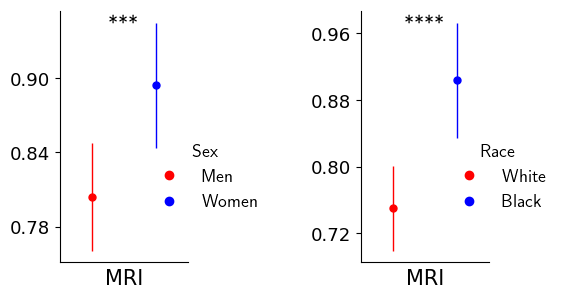

In [80]:
df_total_NIS = pd.read_csv('./NIS_results/MRI_CT_Summary_with_pvalues.csv')
# df_total_NIS['sex'] = df_total_NIS['sex'].replace({'Male':'Men','Female':'Women'})

col_ = 'sex'

df_total_NIS[col_] = df_total_NIS['FEMALE'].replace({
    0:'Men',
    1:'Women'
})

cset1 = ['Men','Women']


df_total_NIS['age_group'] = df_total_NIS['Age_Stratified'].replace(
    {j+1:i for i,j in label_conv_dic.items()}
)
df_total_NIS = df_total_NIS[ (df_total_NIS['age_group']=='19<') & (df_total_NIS['DiseaseType']=='Ischemic')]


fig,axs = plt.subplots(1,2,figsize=(5, 3))
# plt.suptitle(modality, x=0.52, y=0.98, ha='center', fontsize=18)
with plt.style.context(STYLE):
    for imod_,modality in enumerate(['MRI']):        
        ax = axs[imod_]
        data_ = df_total_NIS[df_total_NIS['DiseaseType'] == 'Ischemic']

        # Group data by race and age_group and compute mean and CIs
        data_ = data_[[col_,'age_group',f'Mean_{modality}',f'{modality}_Lower_CI',f'{modality}_Upper_CI']]
        data_['mean'] = data_[f'Mean_{modality}']
        data_['lower_ci'] = data_[f'{modality}_Lower_CI']
        data_['upper_ci'] = data_[f'{modality}_Upper_CI']
        data_['up_yerr'] = data_['upper_ci'] - data_['mean']
        data_['lo_yerr'] = data_['mean'] - data_['lower_ci']
        data_ = data_.set_index([col_,'age_group'])

        # ax = sns.boxenplot(data_, x='age_group', y='MRI', hue=col_ ,ax=ax, palette=palette )
        for i_,ic_ in enumerate(cset1):
            dx_ = ((-1)**i_) *0.1
            y_ = data_.loc[ic_,'mean']
            x_ = np.array( [label_conv_dic[i_] for i_ in y_.index.to_list()] )
            ax.errorbar(x=x_+ -((-1)**i_) *0.1, y=y_, yerr=data_.loc[ic_][['lo_yerr','lo_yerr']].values.T, color=clrs[i_], marker='o', ms=5, ls='none')

        p_values = df_total_NIS[df_total_NIS['DiseaseType']=='Ischemic'][f'{modality}_p-value'].dropna()
        
        for _,xi_ in enumerate(x_[::2]):
            ax.text(0.5,0.97,
                    give_star(p_values.iloc[_]),
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        ax.set_xticks([])
        # ax.set_xticklabels([ f'${i_}$' for i_ in label_conv_dic.keys() ],rotation=45,ha='right', rotation_mode='anchor',fontsize=15)
        ax.yaxis.set_major_locator(plt.MaxNLocator(4,prune='both'))
        ax.set_yticks(ax.get_yticks())  # Set tick positions
        ax.set_yticklabels(ax.get_yticklabels(),rotation=0,ha='right', rotation_mode='anchor',fontsize=13)
        ax.set_ylabel('',fontsize=20)
        ax.set_xlabel(modality,fontsize=15)
        # ax.yaxis.set_label_coords(-0.11, 0.5)
        ax.set_xlim(-0.2,.2)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
    plt.tight_layout()
    # Custom legend
    l0 = mlines.Line2D([], [], color=clrs[0], marker='o', linestyle='None', markersize=6, label='Blue Dot')
    l1 = mlines.Line2D([], [], color=clrs[1], marker='o', linestyle='None', markersize=6, label='Red Dot')
    handles = [l0,l1]
    ax.legend(handles, cset1, title=col_.title(), fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(1.6, 0.5), borderaxespad=0.)
    
    # plt.subplots_adjust(hspace=0)

    # name = f'per_age_group_modalities-sex_modalities'
    # fig.savefig(f'results/figs_young/NIS_{name}.pdf')
    # fig.savefig(f'results/figs_young/NIS_{name}.svg')
    # fig.savefig(f'results/figs_young/NIS_{name}.jpg', dpi=300)

# fig,axs = plt.subplots(1,2,figsize=(5, 3))
# plt.suptitle(modality, x=0.52, y=0.98, ha='center', fontsize=18)
# with plt.style.context(STYLE):

    df_total_NIS = pd.read_csv('./NIS_results/MRI_CT_Race_Summary_with_pvalues.csv')
    df_total_NIS
    
    col_ = 'race'
    
    df_total_NIS[col_] = df_total_NIS['RACE']
    
    cset2 = ['White','Black']
    
    df_total_NIS['age_group'] = df_total_NIS['Age_Stratified'].replace(
        {j+1:i for i,j in label_conv_dic.items()}
    )
    df_total_NIS = df_total_NIS[ (df_total_NIS['age_group']=='19<') & (df_total_NIS['DiseaseType']=='Ischemic')]
    
    for imod_,modality in enumerate(['MRI']):        
        ax = axs[1+imod_]
        data_ = df_total_NIS[df_total_NIS['DiseaseType'] == 'Ischemic']

        # Group data by race and age_group and compute mean and CIs
        data_ = data_[[col_,'age_group',f'Mean_{modality}',f'{modality}_Lower_CI',f'{modality}_Upper_CI']]
        data_['mean'] = data_[f'Mean_{modality}']
        data_['lower_ci'] = data_[f'{modality}_Lower_CI']
        data_['upper_ci'] = data_[f'{modality}_Upper_CI']
        data_['up_yerr'] = data_['upper_ci'] - data_['mean']
        data_['lo_yerr'] = data_['mean'] - data_['lower_ci']
        data_ = data_.set_index([col_,'age_group'])

        # ax = sns.boxenplot(data_, x='age_group', y='MRI', hue=col_ ,ax=ax, palette=palette )
        for i_,ic_ in enumerate(cset2):
            dx_ = ((-1)**i_) *0.1
            y_ = data_.loc[ic_,'mean']
            x_ = np.array( [label_conv_dic[i_] for i_ in y_.index.to_list()] )
            ax.errorbar(x=x_+ -((-1)**i_) *0.1, y=y_, yerr=data_.loc[ic_][['lo_yerr','lo_yerr']].values.T, color=clrs[i_], marker='o', ms=5, ls='none')

        p_values = df_total_NIS[df_total_NIS['DiseaseType']=='Ischemic'][f'{modality}_p-value'].dropna()
        
        for _,xi_ in enumerate(x_[::2]):
            ax.text(0.5,0.97,
                    give_star(p_values.iloc[_]),
                    fontsize = 15,
                    horizontalalignment='center',
                    verticalalignment='center',
                    transform=ax.transAxes, rotation=0)

        ax.set_xticks([])
        # ax.set_xticklabels([ f'${i_}$' for i_ in label_conv_dic.keys() ],rotation=45,ha='right', rotation_mode='anchor',fontsize=15)
        ax.yaxis.set_major_locator(plt.MaxNLocator(4,prune='both'))
        ax.set_yticks(ax.get_yticks())  # Set tick positions
        ax.set_yticklabels(ax.get_yticklabels(),rotation=0,ha='right', rotation_mode='anchor',fontsize=13)
        ax.set_ylabel('',fontsize=20)
        ax.set_xlabel(modality,fontsize=15)
        # ax.yaxis.set_label_coords(-0.11, 0.5)
        ax.set_xlim(-0.2,.2)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
    plt.tight_layout()
    # Custom legend
    l0 = mlines.Line2D([], [], color=clrs[0], marker='o', linestyle='None', markersize=6, label='Blue Dot')
    l1 = mlines.Line2D([], [], color=clrs[1], marker='o', linestyle='None', markersize=6, label='Red Dot')
    handles = [l0,l1]
    ax.legend(handles, cset2, title=col_.title(), fontsize=13, title_fontsize='13', loc='upper right', 
              bbox_to_anchor=(1.5, 0.5), borderaxespad=0.)
    
    # plt.subplots_adjust(hspace=0)

    name = f'per_age_group_modalities-sex_race_modalities'
    fig.savefig(f'results/figs_young/NIS_{name}.pdf')
    fig.savefig(f'results/figs_young/NIS_{name}.svg')
    fig.savefig(f'results/figs_young/NIS_{name}.jpg', dpi=300)

In [ ]:
!zip young_results.zip results/*young/*